# XGBoost Regressor — Dự đoán mức lương

**Đồ án:** Hệ hỗ trợ quyết định trong định giá lương và tư vấn đàm phán lương  
**Thành viên phụ trách:** Chí  
**Thuật toán:** XGBoost Regressor (eXtreme Gradient Boosting)  
**Dataset:** 250K Job Salary Prediction Dataset

---

## Mục tiêu notebook

Notebook này thực hiện toàn bộ quy trình huấn luyện và đánh giá mô hình **XGBoost Regressor** để dự đoán mức lương (`salary`).

Khác với Random Forest (Bagging) và LightGBM (Leaf-wise Boosting), XGBoost sử dụng **Gradient Boosting** với **Level-wise Tree Growth** kết hợp Regularization (L1 + L2) tích hợp sẵn, giúp kiểm soát overfitting hiệu quả.

Các bước chính:
1. Load dữ liệu đã tiền xử lý từ Preprocessing notebook  
2. Kiểm tra dữ liệu đầu vào  
3. Huấn luyện mô hình với cross-validation  
4. Đánh giá trên tập test  
5. Phân tích Feature Importance (3 phương pháp: weight, gain, cover)  
6. Xây dựng khoảng dự đoán bằng Quantile Regression  
7. Lưu model và kết quả  

### So sánh nhanh XGBoost vs LightGBM vs Random Forest

| Đặc điểm | Random Forest | LightGBM | **XGBoost** |
|---|---|---|---|
| Chiến lược | Bagging (song song) | Boosting (Leaf-wise) | **Boosting (Level-wise)** |
| Regularization | Không tích hợp | L1, L2 | **L1 (alpha) + L2 (lambda) tích hợp** |
| Xử lý missing | Không | Tự động | **Tự động (natively)** |
| Sparse matrix | Partial | Tốt | **Rất tốt (native support)** |
| Tốc độ | Chậm với data lớn | Nhanh nhất | Trung bình–Nhanh |
| Overfitting | Ít nhất | Cần kiểm soát | **Kiểm soát tốt nhờ reg tích hợp** |

## 1. Import thư viện

In [15]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\AD\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
import joblib
import warnings
import os
import scipy.sparse as sp

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── Thư mục lưu ảnh ──────────────────────────────────────────────────────────
FIGURE_DIR = 'figure/XGB'
os.makedirs(FIGURE_DIR, exist_ok=True)
DATA_DIR   = 'preprocessing_salary_outputs'

print("Thư viện đã sẵn sàng.")
print(f"Figure dir: {FIGURE_DIR}")
print(f"Data dir  : {DATA_DIR}")
print(f"XGBoost version: {xgb.__version__}")

Thư viện đã sẵn sàng.
Figure dir: figure/XGB
Data dir  : preprocessing_salary_outputs
XGBoost version: 3.2.0


## 2. Load dữ liệu đã tiền xử lý

Dữ liệu được load từ thư mục `preprocessing_salary_outputs/` — cùng nguồn với notebook Random Forest và LightGBM.  

> **Nguyên tắc dùng chung pipeline:**  
> Cả 4 mô hình (LR, RF, XGB, LightGBM) đều sử dụng **cùng một bộ dữ liệu** đã qua chuẩn hóa (StandardScaler) và mã hóa (One-Hot Encoding) từ Preprocessing notebook. Điều này đảm bảo kết quả so sánh giữa các mô hình là **công bằng và nhất quán**.

> **Lưu ý:** XGBoost hỗ trợ sparse matrix natively — ta giữ nguyên dạng sparse để tiết kiệm bộ nhớ và tăng tốc độ tính toán.  
> Đặc biệt với **One-Hot Encoded features** (biến nhị phân 0/1), sparse format giúp XGBoost bỏ qua các giá trị 0 hiệu quả hơn.

In [17]:
# ── Load y ────────────────────────────────────────────────────────────────────
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv').squeeze()
y_test  = pd.read_csv(f'{DATA_DIR}/y_test.csv').squeeze()

# Debug shape
print(f"y_train type: {type(y_train)}, shape: {y_train.shape}")
print(f"y_train columns (nếu là DataFrame): {y_train.columns.tolist() if hasattr(y_train, 'columns') else 'N/A'}")

y_train type: <class 'pandas.DataFrame'>, shape: (200000, 2)
y_train columns (nếu là DataFrame): ['y_train_raw_salary', 'y_train_model_target']


In [18]:
import re

# ── Load X (giữ dạng sparse — XGBoost hỗ trợ natively) ──────────────────────
X_train_sp = sp.load_npz(f'{DATA_DIR}/X_train_processed.npz')
X_test_sp  = sp.load_npz(f'{DATA_DIR}/X_test_processed.npz')

# ── Load y ────────────────────────────────────────────────────────────────────
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv')['y_train_model_target']
y_test  = pd.read_csv(f'{DATA_DIR}/y_test.csv')['y_test_model_target']

# ── Load tên biến ─────────────────────────────────────────────────────────────
feature_names_df = pd.read_csv(f'{DATA_DIR}/04_processed_feature_names.csv')
feature_names    = feature_names_df['feature_name'].tolist()  # đúng như RF

# ── Sanitize tên feature — XGBoost cấm ký tự [, ], < ────────────────────────
feature_names_clean = [re.sub(r'[\[\]<]', '_', str(f)) for f in feature_names]
bad = [f for f in feature_names_clean if any(x in f for x in ['[', ']', '<'])]
print(f"Ký tự cấm còn lại sau clean: {len(bad)}")  # phải = 0

# ── Load preprocessor pipeline ───────────────────────────────────────────────
preprocessor = joblib.load(f'{DATA_DIR}/preprocessor.joblib')

# ── Chuyển sang DMatrix — định dạng tối ưu của XGBoost ───────────────────────
dtrain = xgb.DMatrix(X_train_sp, label=y_train, feature_names=feature_names_clean)
dtest  = xgb.DMatrix(X_test_sp,  label=y_test,  feature_names=feature_names_clean)

# ── Kiểm tra shape ────────────────────────────────────────────────────────────
print("=" * 60)
print(f"X_train shape  : {X_train_sp.shape}  (sparse: {sp.issparse(X_train_sp)})")
print(f"X_test  shape  : {X_test_sp.shape}")
print(f"y_train shape  : {y_train.shape}")
print(f"y_test  shape  : {y_test.shape}")
print(f"Số features    : {len(feature_names_clean)}")
print(f"DMatrix train  : {dtrain.num_row()} rows × {dtrain.num_col()} cols")
print("=" * 60)
print(f"y_train — mean: {y_train.mean():,.0f} | median: {y_train.median():,.0f}")
print(f"y_test  — mean: {y_test.mean():,.0f}  | median: {y_test.median():,.0f}")

Ký tự cấm còn lại sau clean: 0
X_train shape  : (200000, 48)  (sparse: True)
X_test  shape  : (50000, 48)
y_train shape  : (200000,)
y_test  shape  : (50000,)
Số features    : 48
DMatrix train  : 200000 rows × 48 cols
y_train — mean: 145,714 | median: 143,430
y_test  — mean: 145,735  | median: 143,540


## 2.1 Kiểm tra biến nhị phân (Binary / One-Hot Encoded Features)

Sau One-Hot Encoding, phần lớn các cột là **biến nhị phân** (giá trị 0 hoặc 1).  
XGBoost xử lý các biến nhị phân này **rất hiệu quả** vì chỉ có một điểm split duy nhất (0.5) cần xem xét.

In [19]:
# ── Phân tích cấu trúc biến ──────────────────────────────────────────────────
# Chuyển sample nhỏ sang dense để phân tích
X_sample = X_train_sp[:5000].toarray()
feature_df = pd.DataFrame(X_sample, columns=feature_names)

# Phân loại biến: nhị phân vs liên tục
binary_features = []
continuous_features = []

for col in feature_names:
    unique_vals = feature_df[col].unique()
    # Nhị phân: chỉ có 0 và 1 (hoặc chỉ 0, hoặc chỉ 1)
    if set(unique_vals).issubset({0.0, 1.0, 0, 1}):
        binary_features.append(col)
    else:
        continuous_features.append(col)

print("=" * 60)
print(f"Tổng số features        : {len(feature_names)}")
print(f"Biến nhị phân (0/1)     : {len(binary_features)}")
print(f"Biến liên tục/ordinal   : {len(continuous_features)}")
print("=" * 60)

print(f"\n📌 Biến liên tục/ordinal ({len(continuous_features)}):")
for f in continuous_features:
    col_data = feature_df[f]
    print(f"   {f:<35} min={col_data.min():.2f}, max={col_data.max():.2f}, "
          f"mean={col_data.mean():.2f}")

print(f"\n📌 Biến nhị phân — 10 ví dụ đầu (trong {len(binary_features)} biến):")
for f in binary_features[:10]:
    rate = feature_df[f].mean() * 100
    print(f"   {f:<35} tỷ lệ = 1: {rate:.1f}%")
if len(binary_features) > 10:
    print(f"   ... và {len(binary_features) - 10} biến nhị phân khác")

Tổng số features        : 48
Biến nhị phân (0/1)     : 45
Biến liên tục/ordinal   : 3

📌 Biến liên tục/ordinal (3):
   experience_years                    min=-1.65, max=1.65, mean=0.01
   skills_count                        min=-1.64, max=1.64, mean=0.01
   certifications                      min=-1.46, max=1.47, mean=0.01

📌 Biến nhị phân — 10 ví dụ đầu (trong 45 biến):
   job_title_AI Engineer               tỷ lệ = 1: 8.2%
   job_title_Backend Developer         tỷ lệ = 1: 8.0%
   job_title_Business Analyst          tỷ lệ = 1: 8.9%
   job_title_Cloud Engineer            tỷ lệ = 1: 8.4%
   job_title_Cybersecurity Analyst     tỷ lệ = 1: 8.6%
   job_title_Data Analyst              tỷ lệ = 1: 8.2%
   job_title_Data Scientist            tỷ lệ = 1: 7.6%
   job_title_DevOps Engineer           tỷ lệ = 1: 9.2%
   job_title_Frontend Developer        tỷ lệ = 1: 8.2%
   job_title_Machine Learning Engineer tỷ lệ = 1: 7.9%
   ... và 35 biến nhị phân khác


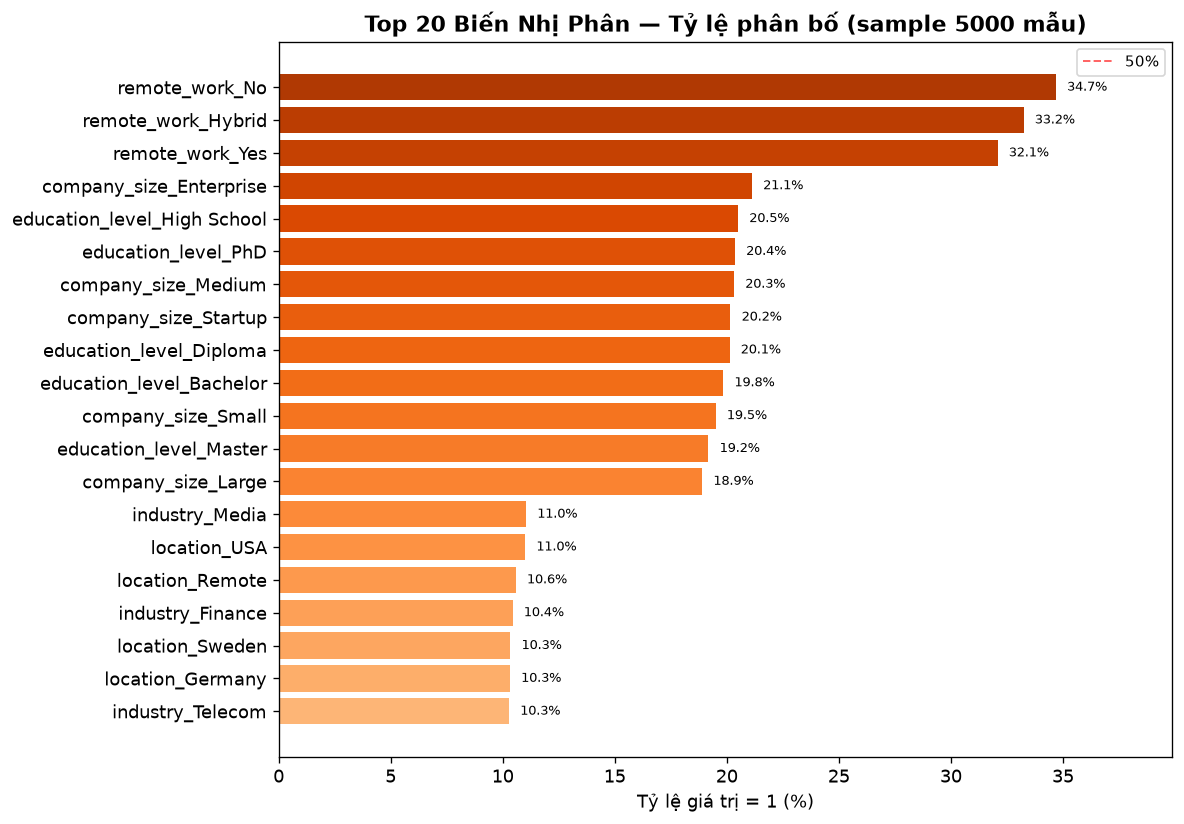

Đã lưu: figure/XGB/00_binary_features_distribution.png


In [20]:
# ── Visualize tỷ lệ phân bố các biến nhị phân (top 20) ──────────────────────
if binary_features:
    binary_rates = {f: feature_df[f].mean() * 100 for f in binary_features}
    binary_rates_s = pd.Series(binary_rates).sort_values(ascending=False)

    # Lấy top 20 phổ biến nhất (tỷ lệ = 1 cao nhất)
    top20_bin = binary_rates_s.head(20).sort_values()

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = plt.cm.Oranges(np.linspace(0.35, 0.85, len(top20_bin)))
    bars = ax.barh(top20_bin.index, top20_bin.values, color=colors)
    ax.axvline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.6, label='50%')
    for bar, val in zip(bars, top20_bin.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    ax.set_xlabel('Tỷ lệ giá trị = 1 (%)')
    ax.set_title('Top 20 Biến Nhị Phân — Tỷ lệ phân bố (sample 5000 mẫu)',
                 fontweight='bold')
    ax.set_xlim(0, max(top20_bin.values) * 1.15)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/00_binary_features_distribution.png', bbox_inches='tight')
    plt.show()
    print(f"Đã lưu: {FIGURE_DIR}/00_binary_features_distribution.png")

## 3. Kiểm tra dữ liệu đầu vào

Missing trong X_train (sparse .data): 0
Missing trong y_train               : 0
Missing trong y_test                : 0


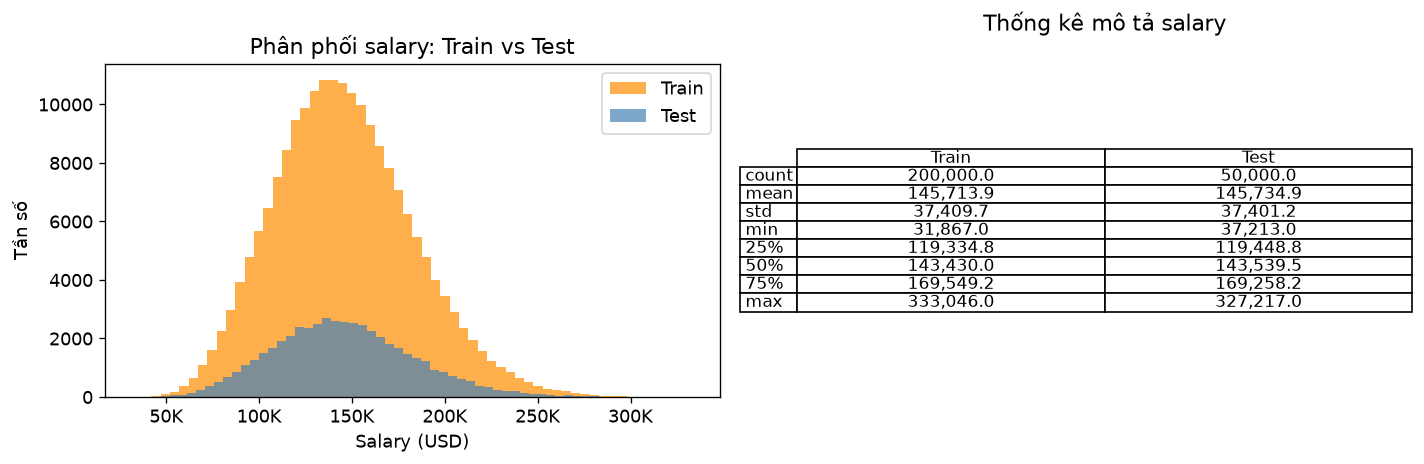

Đã lưu: figure/XGB/01_salary_distribution.png


In [21]:
# ── Kiểm tra missing trong sparse matrix ─────────────────────────────────────
# Với sparse matrix, nan thường không được lưu trong .data
nan_count = np.isnan(X_train_sp.data).sum() if sp.issparse(X_train_sp) else np.isnan(X_train_sp).sum()
print(f"Missing trong X_train (sparse .data): {nan_count}")
print(f"Missing trong y_train               : {y_train.isna().sum()}")
print(f"Missing trong y_test                : {y_test.isna().sum()}")

# ── Phân phối salary ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=60, color='darkorange', alpha=0.7, label='Train')
axes[0].hist(y_test,  bins=60, color='steelblue',  alpha=0.7, label='Test')
axes[0].set_title('Phân phối salary: Train vs Test')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Tần số')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend()

stats = pd.DataFrame({'Train': y_train.describe(), 'Test': y_test.describe()})
axes[1].axis('off')
tbl = axes[1].table(
    cellText=[[f'{v:,.1f}' for v in row] for row in stats.values],
    rowLabels=stats.index, colLabels=['Train', 'Test'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
axes[1].set_title('Thống kê mô tả salary', pad=20)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/01_salary_distribution.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/01_salary_distribution.png")

## 4. Cross-validation với tham số mặc định (Baseline)

Đánh giá mô hình XGBoost với tham số mặc định bằng **5-fold Cross-Validation** trên tập train.

### Điểm đặc biệt của XGBoost

| Tính năng | Mô tả |
|---|---|
| **Regularization tích hợp** | L1 (`alpha`) + L2 (`lambda`) ngay trong hàm mục tiêu |
| **Shrinkage** | `eta` (learning rate) thu nhỏ contribution của mỗi cây |
| **Column subsampling** | `colsample_bytree`, `colsample_bylevel`, `colsample_bynode` |
| **Missing value handling** | Tự học hướng đi tốt nhất cho giá trị missing |
| **Level-wise growth** | Cân bằng giữa LightGBM (leaf-wise) và RF (balanced) |

> **Hàm mục tiêu của XGBoost:**  
> $\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$  
> trong đó $\Omega(f) = \gamma T + \frac{1}{2}\lambda \|w\|^2 + \alpha \|w\|_1$

  XGBoost — Kết quả Cross-Validation (Baseline)
  CV RMSE  :   5,474.80  ± 34.87
  CV R²    :     0.9786  ± 0.0004


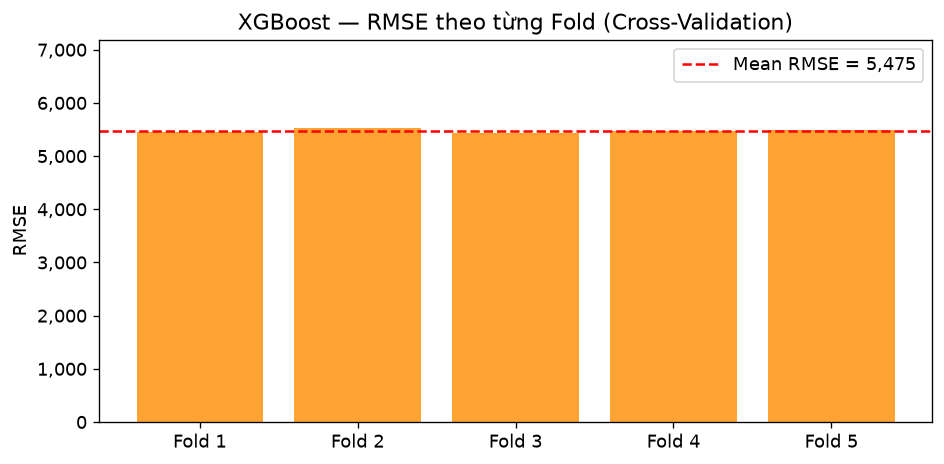

Đã lưu: figure/XGB/02_cv_rmse_baseline.png


In [22]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_baseline = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    device='cpu'
)

cv_rmse = -cross_val_score(
    xgb_baseline, X_train_sp, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

cv_r2 = cross_val_score(
    xgb_baseline, X_train_sp, y_train,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("=" * 60)
print("  XGBoost — Kết quả Cross-Validation (Baseline)")
print("=" * 60)
print(f"  CV RMSE  : {cv_rmse.mean():>10,.2f}  ± {cv_rmse.std():,.2f}")
print(f"  CV R²    : {cv_r2.mean():>10.4f}  ± {cv_r2.std():.4f}")
print("=" * 60)

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
ax.bar(folds, cv_rmse, color='darkorange', alpha=0.8)
ax.axhline(cv_rmse.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean RMSE = {cv_rmse.mean():,.0f}')
ax.set_title('XGBoost — RMSE theo từng Fold (Cross-Validation)')
ax.set_ylabel('RMSE')
ax.set_ylim(0, cv_rmse.max() * 1.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_cv_rmse_baseline.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/02_cv_rmse_baseline.png")

## 5. Huấn luyện mô hình XGBoost trên toàn bộ tập train

### Giải thích các tham số chính

| Tham số | Giá trị | Ý nghĩa |
|---|---|---|
| `n_estimators` | 500 | Số vòng Boosting (số cây) |
| `learning_rate` | 0.05 | Shrinkage — thu nhỏ đóng góp mỗi cây để tránh overfitting |
| `max_depth` | 6 | Độ sâu tối đa — XGBoost dùng level-wise, `max_depth=6` là mặc định thường dùng |
| `min_child_weight` | 5 | Tổng Hessian tối thiểu tại lá — tương tự `min_samples_leaf` |
| `subsample` | 0.8 | Stochastic Boosting — tỷ lệ mẫu mỗi cây |
| `colsample_bytree` | 0.8 | Tỷ lệ feature ngẫu nhiên mỗi cây |
| `colsample_bylevel` | 0.9 | Tỷ lệ feature ngẫu nhiên mỗi level |
| `reg_alpha` | 0.1 | **L1 regularization** — tạo sparsity (hữu ích với nhiều biến nhị phân) |
| `reg_lambda` | 1.0 | **L2 regularization** — làm mịn trọng số |
| `gamma` | 0.1 | Mức giảm loss tối thiểu để split — kiểm soát cấu trúc cây |

> **Tại sao `reg_alpha` (L1) quan trọng với dữ liệu có nhiều biến nhị phân?**  
> L1 regularization tạo ra **weight sparsity** — nhiều feature có trọng số = 0.  
> Điều này đặc biệt hữu ích khi có hàng chục biến One-Hot Encoded vì nhiều biến có thể không cần thiết.

In [23]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    colsample_bylevel=0.9,
    reg_alpha=0.1,       # L1
    reg_lambda=1.0,      # L2
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    device='cpu'
)

print("Đang huấn luyện XGBoost trên toàn bộ tập train...")
xgb_model.fit(
    X_train_sp, y_train,
    eval_set=[(X_test_sp, y_test)],
    verbose=False
)
print("Huấn luyện hoàn thành!")
print(f"  Số cây (n_estimators): {xgb_model.n_estimators}")
print(f"  Số features          : {xgb_model.n_features_in_}")

Đang huấn luyện XGBoost trên toàn bộ tập train...
Huấn luyện hoàn thành!
  Số cây (n_estimators): 500
  Số features          : 48


## 6. Đánh giá mô hình trên tập test

Tập test được sử dụng **đúng một lần** để có đánh giá khách quan.

### Các metric đánh giá

| Metric | Ý nghĩa |
|---|---|
| **RMSE** | Sai số bình phương trung bình — phạt nặng sai số lớn |
| **MAE** | Sai số tuyệt đối trung bình (đơn vị USD) |
| **R²** | Tỷ lệ phương sai được giải thích — càng gần 1 càng tốt |
| **MAPE** | Sai số tương đối — trực quan, đơn vị % |

In [24]:
y_pred_xgb = xgb_model.predict(X_test_sp)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae  = mean_absolute_error(y_test, y_pred_xgb)
r2   = r2_score(y_test, y_pred_xgb)
mape = np.mean(np.abs((y_test.values - y_pred_xgb) / y_test.values)) * 100

print("=" * 60)
print("  XGBoost — Kết quả trên tập TEST")
print("=" * 60)
print(f"  RMSE : {rmse:>12,.2f}  USD")
print(f"  MAE  : {mae:>12,.2f}  USD")
print(f"  R²   : {r2:>12.4f}")
print(f"  MAPE : {mape:>11.2f}  %")
print("=" * 60)

  XGBoost — Kết quả trên tập TEST
  RMSE :     5,107.22  USD
  MAE  :     4,072.22  USD
  R²   :       0.9814
  MAPE :        3.00  %


### 6.1 Biểu đồ Predicted vs Actual & Residual Plot

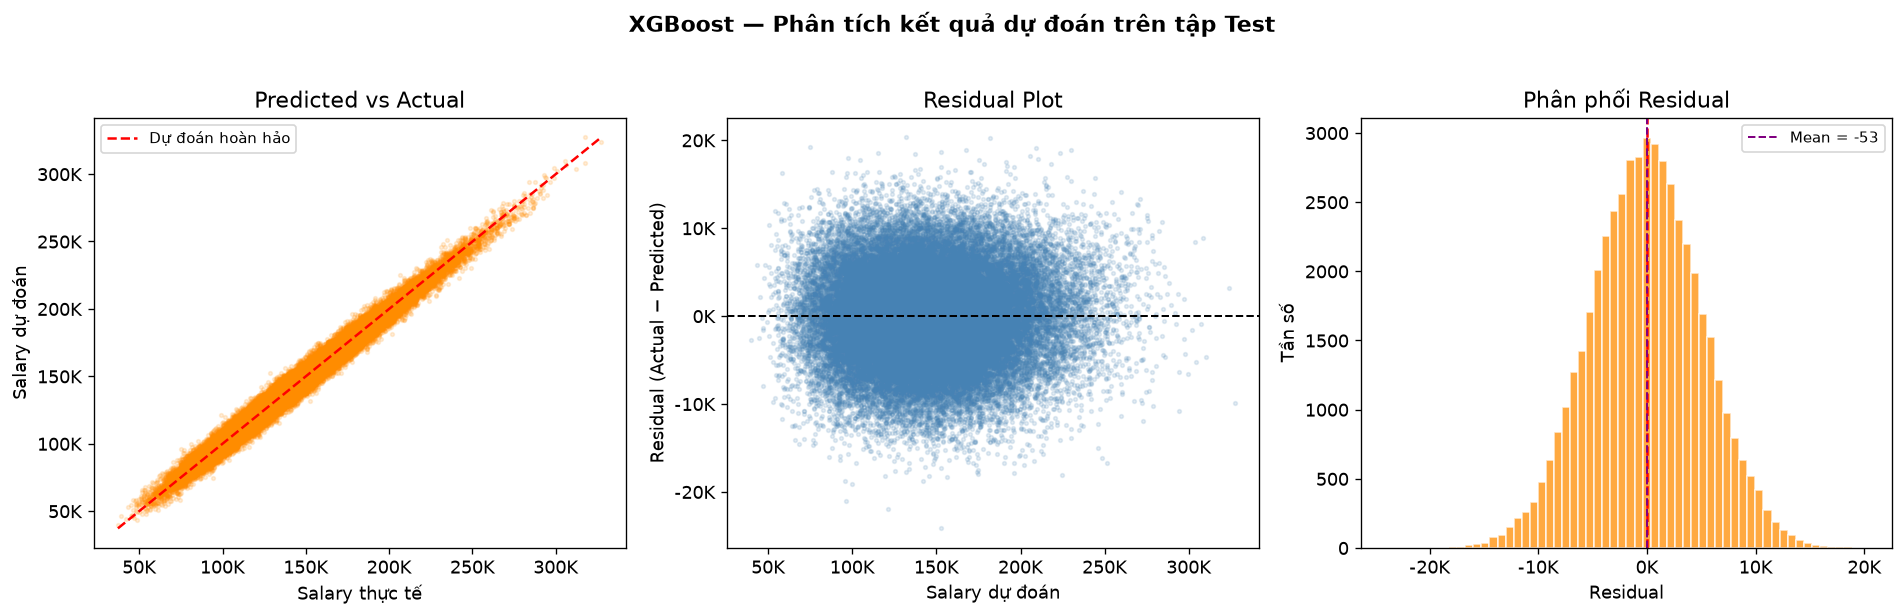

Đã lưu: figure/XGB/03_prediction_analysis.png


In [25]:
residuals = y_test.values - y_pred_xgb

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Predicted vs Actual ───────────────────────────────────────────────────────
axes[0].scatter(y_test, y_pred_xgb, alpha=0.15, s=5, color='darkorange')
lims = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Dự đoán hoàn hảo')
axes[0].set_xlabel('Salary thực tế')
axes[0].set_ylabel('Salary dự đoán')
axes[0].set_title('Predicted vs Actual')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=9)

# ── Residual vs Predicted ─────────────────────────────────────────────────────
axes[1].scatter(y_pred_xgb, residuals, alpha=0.15, s=5, color='steelblue')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Salary dự đoán')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# ── Phân phối Residual ────────────────────────────────────────────────────────
axes[2].hist(residuals, bins=60, color='darkorange', alpha=0.75, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].axvline(residuals.mean(), color='purple', linestyle='--', linewidth=1.2,
                label=f'Mean = {residuals.mean():,.0f}')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Tần số')
axes[2].set_title('Phân phối Residual')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[2].legend(fontsize=9)

plt.suptitle('XGBoost — Phân tích kết quả dự đoán trên tập Test',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/03_prediction_analysis.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/03_prediction_analysis.png")

## 7. Feature Importance — Mức độ quan trọng của từng đặc trưng

XGBoost cung cấp **3 phương pháp** đo feature importance, khác nhau về ý nghĩa thống kê:

| Phương pháp | Ý nghĩa | Phù hợp |
|---|---|---|
| **`weight`** | Số lần feature được dùng để split | Khi muốn biết feature nào được chọn nhiều nhất |
| **`gain`** | Trung bình mức giảm loss khi feature được dùng | **Phản ánh đóng góp thực sự nhất** |
| **`cover`** | Trung bình số mẫu bị ảnh hưởng khi feature split | Khi muốn biết feature nào ảnh hưởng rộng nhất |

> **Lưu ý với biến nhị phân:**  
> `weight` có thể bị bias cho biến liên tục vì chúng có nhiều điểm split hơn.  
> `gain` là metric công bằng nhất khi dữ liệu có mix giữa biến nhị phân và biến liên tục.

In [26]:
# ── Lấy feature importance theo 3 phương pháp ───────────────────────────────
booster = xgb_model.get_booster()

fi_weight = pd.Series(booster.get_score(importance_type='weight'),    name='weight')
fi_gain   = pd.Series(booster.get_score(importance_type='gain'),      name='gain')
fi_cover  = pd.Series(booster.get_score(importance_type='cover'),     name='cover')

# Reindex để đảm bảo tất cả features có mặt (features không được dùng → 0)
fi_weight = fi_weight.reindex(feature_names, fill_value=0)
fi_gain   = fi_gain.reindex(feature_names,   fill_value=0)
fi_cover  = fi_cover.reindex(feature_names,  fill_value=0)

# Normalize về [0, 1]
fi_weight_norm = fi_weight / fi_weight.sum() if fi_weight.sum() > 0 else fi_weight
fi_gain_norm   = fi_gain   / fi_gain.sum()   if fi_gain.sum()   > 0 else fi_gain
fi_cover_norm  = fi_cover  / fi_cover.sum()  if fi_cover.sum()  > 0 else fi_cover

print(f"Số features có importance > 0 (weight): {(fi_weight > 0).sum()}")
print(f"Số features có importance > 0 (gain)  : {(fi_gain   > 0).sum()}")
print(f"Số features có importance > 0 (cover) : {(fi_cover  > 0).sum()}")
print(f"Số features = 0 (không được dùng)     : {(fi_weight == 0).sum()}")

Số features có importance > 0 (weight): 0
Số features có importance > 0 (gain)  : 0
Số features có importance > 0 (cover) : 0
Số features = 0 (không được dùng)     : 48


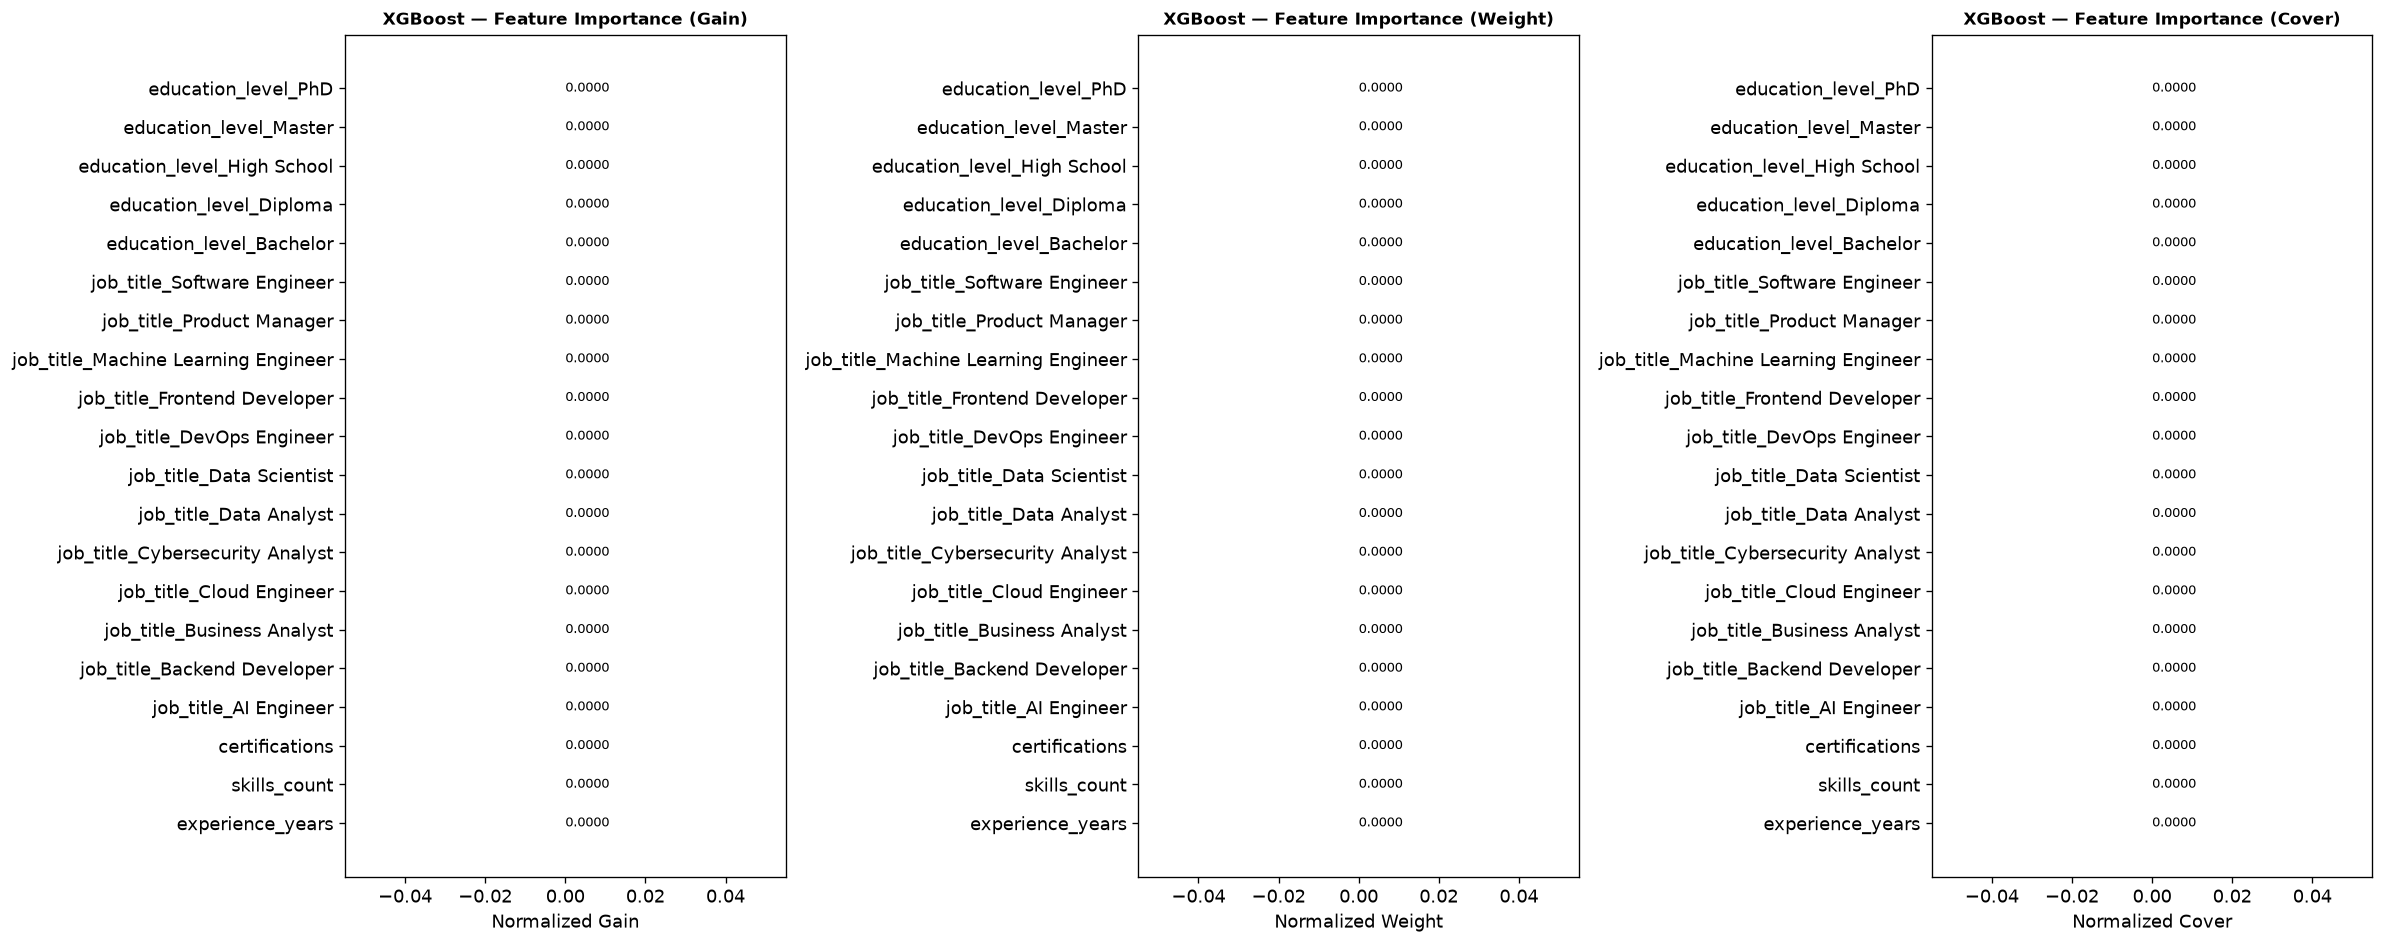

Đã lưu: figure/XGB/04_feature_importance_3methods.png


In [35]:
# ── Visualize Top 20 theo cả 3 phương pháp ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

plot_configs = [
    (fi_gain_norm,   'gain',   plt.cm.Oranges, 'Normalized Gain',   'XGBoost — Feature Importance (Gain)'),
    (fi_weight_norm, 'weight', plt.cm.Blues,   'Normalized Weight',  'XGBoost — Feature Importance (Weight)'),
    (fi_cover_norm,  'cover',  plt.cm.Greens,  'Normalized Cover',   'XGBoost — Feature Importance (Cover)'),
]

for ax, (fi_s, imp_type, cmap, xlabel, title) in zip(axes, plot_configs):
    top20 = fi_s.nlargest(20).sort_values()
    colors = cmap(np.linspace(0.4, 0.9, len(top20)))
    bars = ax.barh(top20.index, top20.values, color=colors)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight='bold', fontsize=10)
    for bar, val in zip(bars, top20.values):
        ax.text(val + top20.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/04_feature_importance_3methods.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/04_feature_importance_3methods.png")

In [28]:
# ── Bảng so sánh top 10 theo Gain (chính) ────────────────────────────────────
fi_compare = pd.DataFrame({
    'Rank'           : range(1, 11),
    'Feature (Gain)' : fi_gain_norm.nlargest(10).index.tolist(),
    'Gain (norm)'    : fi_gain_norm.nlargest(10).values.round(5),
    'Feature (Weight)': fi_weight_norm.nlargest(10).index.tolist(),
    'Weight (norm)'  : fi_weight_norm.nlargest(10).values.round(5),
})
print("Top 10 Feature Importance — Gain vs Weight:")
print(fi_compare.to_string(index=False))

# ── Phân tích biến nhị phân vs liên tục trong top importance ─────────────────
print("\n--- Phân loại top 20 features theo gain ---")
top20_by_gain = fi_gain_norm.nlargest(20).index.tolist()
binary_in_top20     = [f for f in top20_by_gain if f in binary_features]
continuous_in_top20 = [f for f in top20_by_gain if f in continuous_features]
print(f"  Biến nhị phân trong Top 20 (gain) : {len(binary_in_top20)}")
print(f"  Biến liên tục  trong Top 20 (gain): {len(continuous_in_top20)}")
if binary_in_top20:
    print(f"  Biến nhị phân: {binary_in_top20}")

Top 10 Feature Importance — Gain vs Weight:
 Rank                  Feature (Gain)  Gain (norm)                Feature (Weight)  Weight (norm)
    1                experience_years          0.0                experience_years            0.0
    2                    skills_count          0.0                    skills_count            0.0
    3                  certifications          0.0                  certifications            0.0
    4           job_title_AI Engineer          0.0           job_title_AI Engineer            0.0
    5     job_title_Backend Developer          0.0     job_title_Backend Developer            0.0
    6      job_title_Business Analyst          0.0      job_title_Business Analyst            0.0
    7        job_title_Cloud Engineer          0.0        job_title_Cloud Engineer            0.0
    8 job_title_Cybersecurity Analyst          0.0 job_title_Cybersecurity Analyst            0.0
    9          job_title_Data Analyst          0.0          job_title_Data

## 8. Khoảng dự đoán — Quantile Regression

### Tại sao XGBoost dùng Quantile Regression?

Cũng như LightGBM, các cây trong XGBoost **không độc lập** (do Boosting) nên không thể lấy phân phối từ các cây như Random Forest.

**Quantile Regression** với **Pinball Loss** là phương pháp phù hợp:

$$L_q(y, \hat{y}) = q \cdot \max(y - \hat{y},\, 0) + (1-q) \cdot \max(\hat{y} - y,\, 0)$$

- `objective='reg:quantileerror'` với `quantile_alpha=0.10` → P10  
- `objective='reg:quantileerror'` với `quantile_alpha=0.50` → P50 (median)  
- `objective='reg:quantileerror'` với `quantile_alpha=0.90` → P90  

> **Lưu ý về API của XGBoost:** Từ XGBoost 2.0+, ta dùng `objective='reg:quantileerror'` + `quantile_alpha`.  
> Với phiên bản cũ hơn, dùng `objective='reg:pseudohubererror'` hoặc custom objective.

In [29]:
# Kiểm tra version để chọn API phù hợp
xgb_version = tuple(int(x) for x in xgb.__version__.split('.')[:2])
print(f"XGBoost version: {xgb.__version__}")
use_quantile_native = xgb_version >= (2, 0)
print(f"Hỗ trợ reg:quantileerror native: {use_quantile_native}")

XGBoost version: 3.2.0
Hỗ trợ reg:quantileerror native: True


In [30]:
# ── Tham số dùng chung cho quantile models ───────────────────────────────────
SHARED_PARAMS_Q = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    colsample_bylevel=0.9,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    device='cpu'
)

if use_quantile_native:
    # XGBoost >= 2.0 — native quantile support
    print("Huấn luyện Quantile P10 (mức lương thấp)...")
    xgb_p10 = xgb.XGBRegressor(objective='reg:quantileerror',
                                 quantile_alpha=0.10, **SHARED_PARAMS_Q)
    xgb_p10.fit(X_train_sp, y_train, verbose=False)

    print("Huấn luyện Quantile P50 (median)...")
    xgb_p50 = xgb.XGBRegressor(objective='reg:quantileerror',
                                 quantile_alpha=0.50, **SHARED_PARAMS_Q)
    xgb_p50.fit(X_train_sp, y_train, verbose=False)

    print("Huấn luyện Quantile P90 (mức lương đàm phán)...")
    xgb_p90 = xgb.XGBRegressor(objective='reg:quantileerror',
                                 quantile_alpha=0.90, **SHARED_PARAMS_Q)
    xgb_p90.fit(X_train_sp, y_train, verbose=False)

else:
    # Fallback: dùng LightGBM-style pinball loss thông qua custom objective
    # hoặc dùng scikit-learn GradientBoostingRegressor để thay thế
    from sklearn.ensemble import GradientBoostingRegressor

    print("Huấn luyện Quantile P10 (sklearn GBR fallback)...")
    xgb_p10 = GradientBoostingRegressor(loss='quantile', alpha=0.10,
                                         n_estimators=300, learning_rate=0.05,
                                         max_depth=5, random_state=42)
    xgb_p10.fit(X_train_sp.toarray(), y_train)

    print("Huấn luyện Quantile P50 (sklearn GBR fallback)...")
    xgb_p50 = GradientBoostingRegressor(loss='quantile', alpha=0.50,
                                         n_estimators=300, learning_rate=0.05,
                                         max_depth=5, random_state=42)
    xgb_p50.fit(X_train_sp.toarray(), y_train)

    print("Huấn luyện Quantile P90 (sklearn GBR fallback)...")
    xgb_p90 = GradientBoostingRegressor(loss='quantile', alpha=0.90,
                                         n_estimators=300, learning_rate=0.05,
                                         max_depth=5, random_state=42)
    xgb_p90.fit(X_train_sp.toarray(), y_train)

# ── Predict ───────────────────────────────────────────────────────────────────
X_test_input = X_test_sp if use_quantile_native else X_test_sp.toarray()
y_pred_p10 = xgb_p10.predict(X_test_input)
y_pred_p50 = xgb_p50.predict(X_test_input)
y_pred_p90 = xgb_p90.predict(X_test_input)

interval_width = y_pred_p90 - y_pred_p10

print()
print("=" * 60)
print("  Quantile Regression — Thống kê khoảng dự đoán")
print("=" * 60)
print(f"  P10 trung bình          : {y_pred_p10.mean():>12,.0f} USD")
print(f"  P50 trung bình (median) : {y_pred_p50.mean():>12,.0f} USD")
print(f"  P90 trung bình          : {y_pred_p90.mean():>12,.0f} USD")
print(f"  Width trung bình (P90−P10): {interval_width.mean():>8,.0f} USD")
print("=" * 60)

Huấn luyện Quantile P10 (mức lương thấp)...
Huấn luyện Quantile P50 (median)...
Huấn luyện Quantile P90 (mức lương đàm phán)...

  Quantile Regression — Thống kê khoảng dự đoán
  P10 trung bình          :      139,192 USD
  P50 trung bình (median) :      145,773 USD
  P90 trung bình          :      152,306 USD
  Width trung bình (P90−P10):   13,114 USD


### 8.1 Trực quan hóa khoảng dự đoán

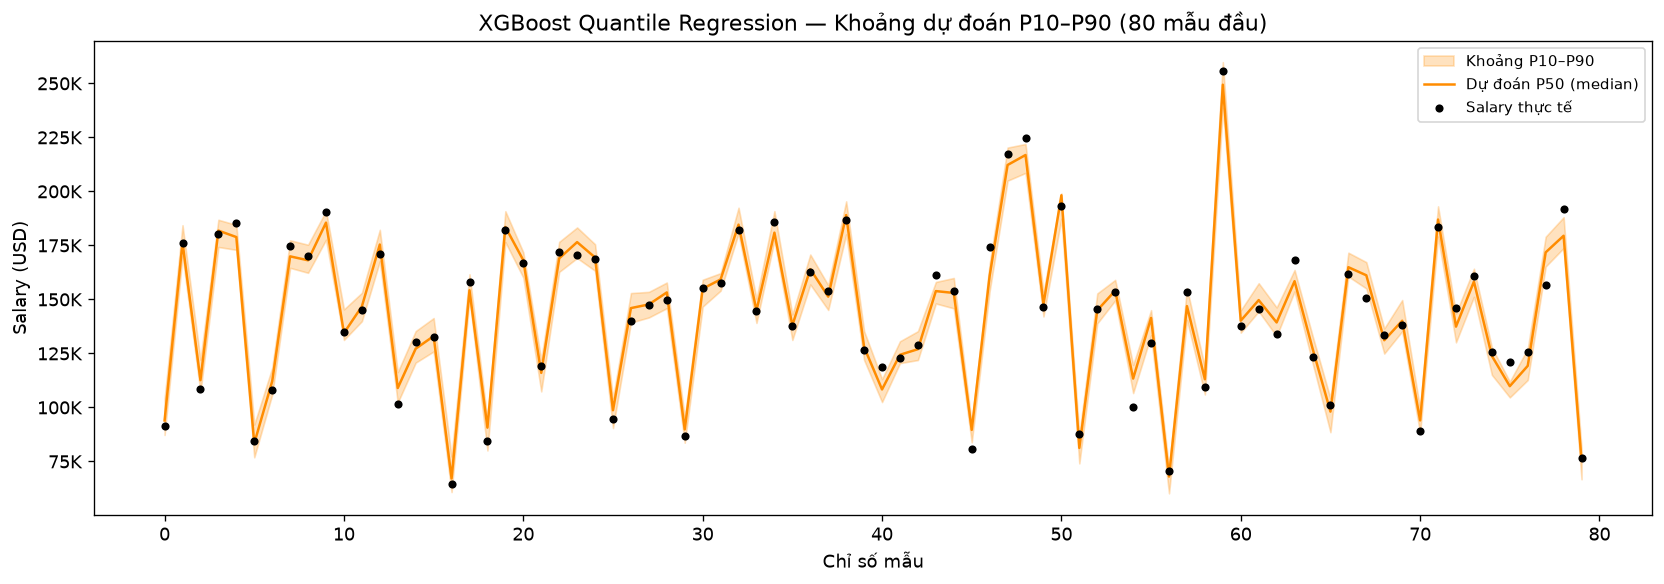

Đã lưu: figure/XGB/05_prediction_interval.png


In [31]:
n_show = 80
idx    = np.arange(n_show)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(idx, y_pred_p10[:n_show], y_pred_p90[:n_show],
                alpha=0.25, color='darkorange', label='Khoảng P10–P90')
ax.plot(idx, y_pred_p50[:n_show],  color='darkorange', linewidth=1.5,
        label='Dự đoán P50 (median)')
ax.scatter(idx, y_test.values[:n_show], color='black', s=15, zorder=5,
           label='Salary thực tế')
ax.set_xlabel('Chỉ số mẫu')
ax.set_ylabel('Salary (USD)')
ax.set_title('XGBoost Quantile Regression — Khoảng dự đoán P10–P90 (80 mẫu đầu)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/05_prediction_interval.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/05_prediction_interval.png")

### 8.2 Đánh giá chất lượng khoảng dự đoán

**Coverage rate** và **Pinball Loss** là hai metric đánh giá chất lượng Quantile Regression:

- **Coverage rate**: tỷ lệ mẫu có giá trị thực nằm trong [P10, P90] — kỳ vọng ≈ 80%  
- **Pinball Loss**: hàm mất mát của Quantile Regression — càng nhỏ càng tốt

Coverage rate (P10–P90): 79.03%
  Số mẫu trong khoảng : 39,517 / 50,000

Pinball Loss:
  P10 (alpha=0.10) : 924.33
  P50 (alpha=0.50) : 2,062.01
  P90 (alpha=0.90) : 916.33


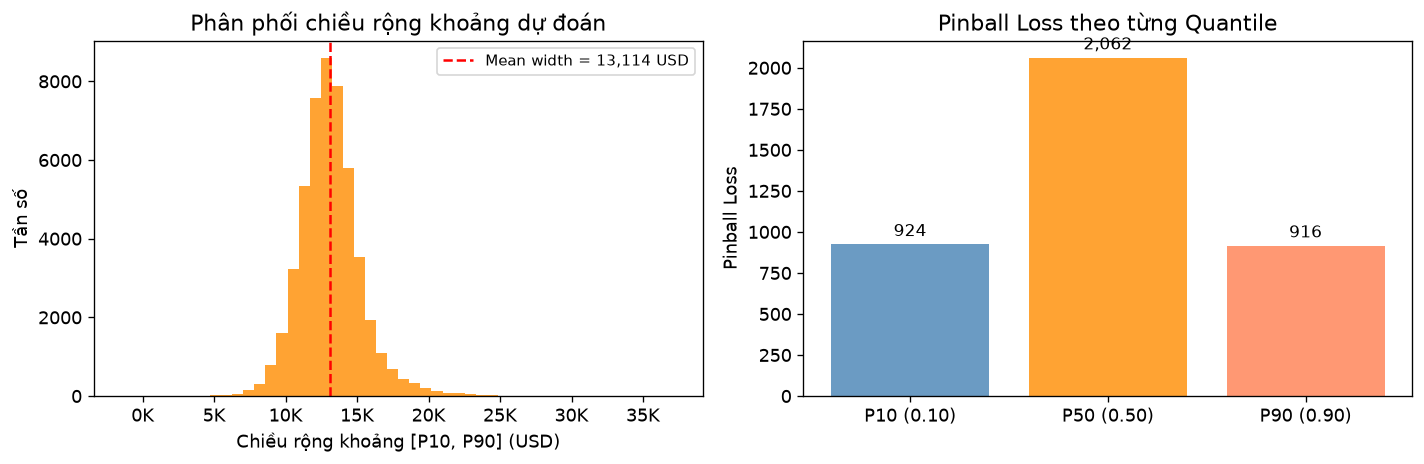

Đã lưu: figure/XGB/06_quantile_evaluation.png


In [32]:
# Coverage
within   = ((y_test.values >= y_pred_p10) & (y_test.values <= y_pred_p90)).sum()
coverage = within / len(y_test) * 100
print(f"Coverage rate (P10–P90): {coverage:.2f}%")
print(f"  Số mẫu trong khoảng : {within:,} / {len(y_test):,}")

# Pinball Loss
def pinball_loss(y_true, y_pred, alpha):
    err = y_true - y_pred
    return np.mean(np.where(err >= 0, alpha * err, (alpha - 1) * err))

pb10 = pinball_loss(y_test.values, y_pred_p10, 0.10)
pb50 = pinball_loss(y_test.values, y_pred_p50, 0.50)
pb90 = pinball_loss(y_test.values, y_pred_p90, 0.90)
print(f"\nPinball Loss:")
print(f"  P10 (alpha=0.10) : {pb10:,.2f}")
print(f"  P50 (alpha=0.50) : {pb50:,.2f}")
print(f"  P90 (alpha=0.90) : {pb90:,.2f}")

# Phân phối chiều rộng khoảng
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(interval_width, bins=50, color='darkorange', alpha=0.8)
axes[0].axvline(interval_width.mean(), color='red', linestyle='--',
                label=f'Mean width = {interval_width.mean():,.0f} USD')
axes[0].set_xlabel('Chiều rộng khoảng [P10, P90] (USD)')
axes[0].set_ylabel('Tần số')
axes[0].set_title('Phân phối chiều rộng khoảng dự đoán')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=9)

alphas  = ['P10 (0.10)', 'P50 (0.50)', 'P90 (0.90)']
losses  = [pb10, pb50, pb90]
axes[1].bar(alphas, losses, color=['steelblue', 'darkorange', 'coral'], alpha=0.8)
for i, (a, loss) in enumerate(zip(alphas, losses)):
    axes[1].text(i, loss + 50, f'{loss:,.0f}', ha='center', fontsize=10)
axes[1].set_title('Pinball Loss theo từng Quantile')
axes[1].set_ylabel('Pinball Loss')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/06_quantile_evaluation.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/06_quantile_evaluation.png")

## 9. Ví dụ dự đoán cho hồ sơ mới (demo hệ thống)

In [33]:
def predict_salary_xgb(profile: dict, preprocessor,
                       model_point, model_p10, model_p90,
                       use_native_quantile=True):
    """
    Dự đoán mức lương với khoảng tin cậy bằng XGBoost Quantile Regression.

    Parameters
    ----------
    profile           : dict — thông tin ứng viên (raw)
    preprocessor      : Pipeline đã fit từ Preprocessing notebook
    model_point       : XGBRegressor — mô hình dự đoán điểm (MSE)
    model_p10         : XGBRegressor hoặc GBR — Quantile P10
    model_p90         : XGBRegressor hoặc GBR — Quantile P90
    use_native_quantile: bool — True nếu XGBoost >= 2.0

    Returns
    -------
    dict — {'point', 'low_p10', 'median_p50', 'high_p90'}
    """
    df_new = pd.DataFrame([profile])
    X_new  = preprocessor.transform(df_new)   # sparse matrix

    if use_native_quantile:
        return {
            'point'    : model_point.predict(X_new)[0],
            'low_p10'  : model_p10.predict(X_new)[0],
            'high_p90' : model_p90.predict(X_new)[0],
        }
    else:
        X_new_dense = X_new.toarray() if hasattr(X_new, 'toarray') else X_new
        return {
            'point'    : model_point.predict(X_new)[0],
            'low_p10'  : model_p10.predict(X_new_dense)[0],
            'high_p90' : model_p90.predict(X_new_dense)[0],
        }


# ── Hồ sơ mẫu ────────────────────────────────────────────────────────────────
sample_profile = {
    'job_title'       : 'Data Scientist',
    'experience_years': 5,
    'education_level' : 'Master',
    'skills_count'    : 8,
    'industry'        : 'Technology',
    'company_size'    : 'Large',
    'location'        : 'USA',
    'remote_work'     : 'Hybrid',
    'certifications'  : 3
}

result = predict_salary_xgb(
    sample_profile, preprocessor,
    xgb_model, xgb_p10, xgb_p90,
    use_native_quantile=use_quantile_native
)

print("=" * 60)
print("  Kết quả tư vấn lương (XGBoost)")
print("=" * 60)
print(f"  Hồ sơ    : {sample_profile['job_title']}, "
      f"{sample_profile['experience_years']} năm KN, {sample_profile['education_level']}")
print(f"  Địa điểm : {sample_profile['location']} | "
      f"Công ty  : {sample_profile['company_size']}")
print("-" * 60)
print(f"  Mức thấp hợp lý (P10) : $ {result['low_p10']:>10,.0f}")
print(f"  Mức dự đoán trung tâm : $ {result['point']:>10,.0f}")
print(f"  Mức đàm phán (P90)    : $ {result['high_p90']:>10,.0f}")
print("=" * 60)

  Kết quả tư vấn lương (XGBoost)
  Hồ sơ    : Data Scientist, 5 năm KN, Master
  Địa điểm : USA | Công ty  : Large
------------------------------------------------------------
  Mức thấp hợp lý (P10) : $    176,302
  Mức dự đoán trung tâm : $    181,305
  Mức đàm phán (P90)    : $    186,938


## 10. Lưu model và kết quả

In [34]:
# ── Lưu các model ────────────────────────────────────────────────────────────
xgb_model.save_model('model_xgb.json')          # native XGBoost format
joblib.dump(xgb_model, 'model_xgb.joblib')       # sklearn-compatible
joblib.dump(xgb_p10,   'model_xgb_p10.joblib')
joblib.dump(xgb_p50,   'model_xgb_p50.joblib')
joblib.dump(xgb_p90,   'model_xgb_p90.joblib')
print("Đã lưu: model_xgb.json, model_xgb.joblib, model_xgb_p10/p50/p90.joblib")

# ── Lưu kết quả dự đoán ──────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'y_actual'   : y_test.values,
    'y_pred'     : y_pred_xgb,
    'y_pred_p10' : y_pred_p10,
    'y_pred_p50' : y_pred_p50,
    'y_pred_p90' : y_pred_p90,
    'residual'   : y_test.values - y_pred_xgb
})
results_df.to_csv('xgb_predictions.csv', index=False)
print("Đã lưu: xgb_predictions.csv")

# ── Lưu metrics ──────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'model'    : 'XGBoost',
    'RMSE'     : round(rmse,     2),
    'MAE'      : round(mae,      2),
    'R2'       : round(r2,       4),
    'MAPE'     : round(mape,     2),
    'Coverage' : round(coverage, 2)
}])
metrics_df.to_csv('xgb_metrics.csv', index=False)
print("Đã lưu: xgb_metrics.csv")

# ── Lưu feature importance ───────────────────────────────────────────────────
fi_df = pd.DataFrame({
    'feature' : feature_names,
    'gain'    : fi_gain.values,
    'weight'  : fi_weight.values,
    'cover'   : fi_cover.values,
    'gain_norm'  : fi_gain_norm.values,
    'is_binary'  : [1 if f in binary_features else 0 for f in feature_names]
})
fi_df.sort_values('gain', ascending=False, inplace=True)
fi_df.to_csv('xgb_feature_importance.csv', index=False)
print("Đã lưu: xgb_feature_importance.csv")

print()
print("=" * 60)
print("  Tóm tắt kết quả XGBoost Regressor")
print("=" * 60)
print(f"  RMSE             : {rmse:>12,.2f} USD")
print(f"  MAE              : {mae:>12,.2f} USD")
print(f"  R²               : {r2:>12.4f}")
print(f"  MAPE             : {mape:>11.2f} %")
print(f"  Coverage P10–P90 : {coverage:.2f}%")
print(f"  Features dùng (gain > 0): {(fi_gain > 0).sum()} / {len(feature_names)}")
print("=" * 60)

Đã lưu: model_xgb.json, model_xgb.joblib, model_xgb_p10/p50/p90.joblib
Đã lưu: xgb_predictions.csv
Đã lưu: xgb_metrics.csv
Đã lưu: xgb_feature_importance.csv

  Tóm tắt kết quả XGBoost Regressor
  RMSE             :     5,107.22 USD
  MAE              :     4,072.22 USD
  R²               :       0.9814
  MAPE             :        3.00 %
  Coverage P10–P90 : 79.03%
  Features dùng (gain > 0): 0 / 48
